In [1]:
print("Hello World")

Hello World


In [2]:
import cv2
import numpy as np


ModuleNotFoundError: No module named 'cv2'

In [3]:
# Load image (replace 'your_image.jpg' with your file path)
img = cv2.imread('ILSVRC2012_val_00000001.JPEG')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
img.shape

(375, 500, 3)

In [4]:
# Resize to 224x224
img_resized = cv2.resize(img, (224, 224))
img_resized.shape



(224, 224, 3)

In [5]:
np.max(img_resized)

np.uint8(247)

In [6]:
np.min(img_resized)

np.uint8(14)

In [7]:
# Convert to int8 range [-128, 127] (simulate quantization)
# You can adjust this quantization according to your Gemmini configuration
img_quantized = np.clip((img_resized.astype(np.int32) - 128), -128, 127).astype(np.int8)
#img_quantized

In [8]:
np.max(img_quantized)

np.int8(119)

In [9]:
np.min(img_quantized)

np.int8(-114)

In [35]:
"""
def format_to_gemmini_syntax(img_array):
    h, w, c = img_array.shape
    assert (h, w, c) == (224, 224, 3), "Expected 224x224 RGB image"

    # We'll just format the first few pixels for demonstration
    output = "static const elem_t images[1][224][224][3] row_align(1) = {\n{{{"

    for y in range(h):
        row = []
        for x in range(w):
            pixel = img_array[y, x]
            row.append(f"{{{pixel[0]},{pixel[1]},{pixel[2]}}}")
        output += ",".join(row)
        if y != h - 1:
            output += "},\n{"
    output += "}}};"
    return output
    """

In [10]:
def format_to_gemmini_syntax(images):
    """
    Takes a list of images (shape: [n, 224, 224, 3]) and returns a string in Gemmini syntax.
    """
    n = len(images)
    assert all(img.shape == (224, 224, 3) for img in images), "All images must be 224x224 RGB"

    output = f"static const elem_t images[{n}][224][224][3] row_align(1) = {{\n"

    for img_idx, img in enumerate(images):
        output += "  {{\n"
        for y in range(224):
            row = []
            for x in range(224):
                pixel = img[y, x]
                row.append(f"{{{pixel[0]},{pixel[1]},{pixel[2]}}}")
            row_str = ",".join(row)
            if y < 223:
                output += f"    {{{row_str}}},\n"
            else:
                output += f"    {{{row_str}}}\n"
        output += "  }"
        if img_idx < n - 1:
            output += ",\n"
        else:
            output += "\n"
    output += "};\n"
    return output


In [11]:
"""def process_images_to_gemmini_header(image_paths, output_file="images.h"):
    
    #Loads images, resizes, quantizes, and writes them to a Gemmini-compatible .h file.
    

    all_images = []

    for path in image_paths:
        img = cv2.imread(path)
        if img is None:
            raise FileNotFoundError(f"Could not open image: {path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (224, 224))

        # Quantize: int8 range [-128, 127] centered around 0
        img_quantized = np.clip((img_resized.astype(np.int32) - 128), -128, 127).astype(np.int8)
        all_images.append(img_quantized)

    # Format all to Gemmini C syntax
    header_str = format_to_gemmini_syntax(all_images)

    with open(output_file, "w") as f:
        f.write(header_str)

    print(f"✅ Generated '{output_file}' with {len(image_paths)} images.")"""

In [12]:
image_paths = ["ILSVRC2012_val_00000001.JPEG", "ILSVRC2012_val_00000002.JPEG", "ILSVRC2012_val_00000003.JPEG", "ILSVRC2012_val_00000004.JPEG","ILSVRC2012_val_00000005.JPEG","ILSVRC2012_val_00000006.JPEG","ILSVRC2012_val_00000007.JPEG","ILSVRC2012_val_00000008.JPEG"]
process_images_to_gemmini_header(image_paths)

✅ Generated 'images.h' with 8 images.


# Actual Function

In [13]:
def load_and_preprocess_image(path):
    """Loads, resizes, and converts an image to RGB."""
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Failed to load image: {path}")
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


In [16]:
def quantize_image(img):
        """Quantizes image to int8 range centered at 0 (Gemmini-style)."""
        #return img.astype(np.int32) - 128
        return np.clip((img.astype(np.int32) - 128), -128, 127).astype(np.int8)

In [17]:
def format_images_to_header(images):
        """Formats a list of quantized images to Gemmini-compatible C array syntax."""
        n = len(images)
        output = f"static const elem_t images[{n}][224][224][3] row_align(1) = {{\n"

        for img_idx, img in enumerate(images):
            output += "  {\n"
            for y in range(224):
                row = []
                for x in range(224):
                    pixel = img[y, x]
                    row.append(f"{{{pixel[0]},{pixel[1]},{pixel[2]}}}")
                output += "    {" + ",".join(row) + "}"
                output += ",\n" if y < 223 else "\n"
            output += "  }" + (",\n" if img_idx < n - 1 else "\n")
        output += "};\n"
        return output

In [18]:
def create_gemmini_image_header(image_paths, output_file="images.h"):
    """
    Loads a list of image paths, quantizes them for Gemmini, formats into C header, and saves to file.
    Each image must be RGB and will be resized to 224x224 and converted to int8 format.
    """

    # --- Main pipeline ---
    processed_images = []
    for path in image_paths:
        img = load_and_preprocess_image(path)
        img_q = quantize_image(img)
        processed_images.append(img_q)

    header_str = format_images_to_header(processed_images)

    with open(output_file, "w") as f:
        f.write(header_str)

    print(f"✅ Header file '{output_file}' created with {len(image_paths)} image(s).")

In [19]:
image_paths = ["ILSVRC2012_val_00000001.JPEG", "ILSVRC2012_val_00000002.JPEG", "ILSVRC2012_val_00000003.JPEG", "ILSVRC2012_val_00000004.JPEG","ILSVRC2012_val_00000005.JPEG","ILSVRC2012_val_00000006.JPEG","ILSVRC2012_val_00000007.JPEG","ILSVRC2012_val_00000008.JPEG"]
create_gemmini_image_header(image_paths, output_file="images.h")

✅ Header file 'images.h' created with 8 image(s).


# Create .bin file

In [107]:
import numpy as np
import cv2
import os
from glob import glob
from PIL import Image

In [108]:
# --- 1. Load and preprocess the image (same as before) ---

def normalize_image(img):
    # Using ImageNet RGB means and stds (common for MobileNet)
    mean = np.array([123.68, 116.779, 103.939])
    std = np.array([58.393, 57.12, 57.375])
    return ((img - mean) / std).astype(np.float32)



def scaled_center_crop(img, scale=0.875):
    # Ensure scale is in (0, 1], e.g., 0.875 = 87.5% of the short edge
    width, height = img.size
    short_edge = min(width, height)
    crop_size = int(short_edge * scale)

    left = (width - crop_size) // 2
    top = (height - crop_size) // 2
    right = left + crop_size
    bottom = top + crop_size

    return img.crop((left, top, right, bottom))




def load_and_preprocess_image(path, crop_size=224):
    img = Image.open(path).convert("RGB")
    

    # Resize so that the shorter side = 256 (preserve aspect ratio)
    """
    w, h = img.size
    if w < h:
        new_w = 256
        new_h = int(256 * h / w)
    else:
        new_h = 256
        new_w = int(256 * w / h)
    img = img.resize((new_w, new_h), Image.LANCZOS)

    # Center crop to 224×224
    left = (new_w - crop_size) // 2
    top = (new_h - crop_size) // 2
    img = img.crop((left, top, left + crop_size, top + crop_size))"""
    # Step 1: Center crop to square
    width, height = img.size
    short_edge = min(width, height)
    left = (width - short_edge) // 2
    top = (height - short_edge) // 2
    right = left + short_edge
    bottom = top + short_edge
    img = img.crop((left, top, right, bottom))

    #img = scaled_center_crop(img, scale=0.875)

    # Step 2: Resize to 224x224
    img = img.resize((224, 224), Image.LANCZOS)

    return np.array(img)

    
# --- 2. Quantize the image (same as before) ---
def quantize_image(img):
    """Quantizes image to int8 range centered at 0 (Gemmini-style)."""
    #return np.clip((img.astype(np.int32) - 128+30), -128, 127).astype(np.int8)

    # Convert to int32 and center at zero
    shifted = img.astype(np.int32) - 128
    
    # Original int8 full range
    orig_min, orig_max = -128, 127
    
    # Target range
    target_min, target_max = -70, 85        # 80 is okay
    
    # Scale factor to fit original range into target range
    scale = (target_max - target_min) / (orig_max - orig_min)
    
    # Apply scaling
    rescaled = shifted * scale
    
    # Round and convert back to int8
    return np.round(rescaled).astype(np.int8)


     # Normalize to [-1, 1]
    #img = img.astype(np.float32) / 127.5 - 1.0
    # Scale to int8
    #return np.clip(img * 128, -128, 127).astype(np.int8)

# --- 3. Write images to a binary file (NEW) ---
def save_images_to_binary(images, output_file="images.bin"):
    """
    Saves a list of quantized images into a single binary file.
    Images are stored sequentially (no separators, no metadata).
    """
    with open(output_file, "wb") as f:
        for img in images:
            f.write(img.tobytes())  # Write raw int8 data
    print(f"✅ Binary file '{output_file}' created with {len(images)} image(s).")

# --- 4. Main pipeline ---
def create_gemmini_image_binary(image_paths, output_file="images.bin"):
    """
    Loads image paths, quantizes them for Gemmini, and saves into a binary file.
    """
    processed_images = []
    for path in image_paths:
        img = load_and_preprocess_image(path)
        img_q = quantize_image(img)
        # channel change
        #img_chw = np.transpose(img_q, (2, 0, 1))  # [HWC] → [CHW]
        processed_images.append(img_q)

    save_images_to_binary(processed_images, output_file=output_file)


#img = cv2.resize(img, (224, 224))
# Example Usage
image_paths = glob("./Images/*.JPEG")+ glob("./Images/*.jpeg")
# Sort by filename to preserve correct order
image_paths = sorted(image_paths)

create_gemmini_image_binary(image_paths, output_file="images.bin")

✅ Binary file 'images.bin' created with 1001 image(s).


In [ ]:


def load_and_preprocess_image(path):
    """Loads, resizes, and converts an image to RGB."""
    """
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Failed to load image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # High-quality downscale
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_LANCZOS4)
    
    return img

    
    """
    img = Image.open(path).convert("RGB")

    # Progressive downscaling if input is much larger
    if max(img.size) > 2 * 224:
        w, h = img.size
        while w > 2 * 224 and h > 2 * 224:
            w //= 2
            h //= 2
            img = img.resize((w, h), Image.BOX)
    
    # Final high-quality resize
    #img = img.resize((224, 224), Image.LANCZOS)
    img = img.resize((256, 256), Image.LANCZOS)
    img = center_crop(np.array(img), crop_size=224)
    return np.array(img)

In [7]:
image_paths = glob("./Images/*.JPEG") + glob("./Images/*.jpeg")
# Sort by filename to preserve correct order
image_paths = sorted(image_paths)
image_paths

['./Images/ILSVRC2012_val_00023992.JPEG',
 './Images/ILSVRC2012_val_00023993.JPEG',
 './Images/ILSVRC2012_val_00023994.JPEG',
 './Images/ILSVRC2012_val_00023995.JPEG',
 './Images/ILSVRC2012_val_00023996.JPEG',
 './Images/ILSVRC2012_val_00023997.JPEG',
 './Images/ILSVRC2012_val_00023998.JPEG',
 './Images/ILSVRC2012_val_00023999.JPEG',
 './Images/ILSVRC2012_val_00024000.JPEG',
 './Images/ILSVRC2012_val_00024001.JPEG',
 './Images/ILSVRC2012_val_00024002.JPEG',
 './Images/ILSVRC2012_val_00024003.JPEG',
 './Images/ILSVRC2012_val_00024004.JPEG',
 './Images/ILSVRC2012_val_00024005.JPEG',
 './Images/ILSVRC2012_val_00024006.JPEG',
 './Images/ILSVRC2012_val_00024007.JPEG',
 './Images/ILSVRC2012_val_00024008.JPEG',
 './Images/ILSVRC2012_val_00024009.JPEG',
 './Images/ILSVRC2012_val_00024010.JPEG',
 './Images/ILSVRC2012_val_00024011.JPEG',
 './Images/ILSVRC2012_val_00024012.JPEG',
 './Images/ILSVRC2012_val_00024013.JPEG',
 './Images/ILSVRC2012_val_00024014.JPEG',
 './Images/ILSVRC2012_val_00024015

# Tests

In [92]:
# Constants
NUM_IMAGES = 200
HEIGHT = 224
WIDTH = 224
CHANNELS = 3
IMAGE_SIZE = HEIGHT * WIDTH * CHANNELS

# Load binary file as int8
with open("images.bin", "rb") as f:
    data = np.frombuffer(f.read(), dtype=np.int8)

# Check size
expected_size = NUM_IMAGES * IMAGE_SIZE
if data.size < expected_size:
    raise ValueError(f"Expected at least {expected_size} elements, got {data.size}")

# Reshape to (NUM_IMAGES, HEIGHT, WIDTH, CHANNELS)
images = data.reshape((NUM_IMAGES, HEIGHT, WIDTH, CHANNELS))

# Print first 5 pixels of the first image
print("🔍 First 5 pixels of image 0:")
for i in range(5):
    row = i // WIDTH
    col = i % WIDTH
    pixel = images[0, row, col]
    print(f"Pixel {i}: R={pixel[0]}, G={pixel[1]}, B={pixel[2]}")

🔍 First 5 pixels of image 0:
Pixel 0: R=-23, G=-56, B=-71
Pixel 1: R=-31, G=-52, B=-72
Pixel 2: R=-33, G=-49, B=-71
Pixel 3: R=-13, G=-36, B=-48
Pixel 4: R=-21, G=-45, B=-61


# Reconstructing the 5th image of images200.bin

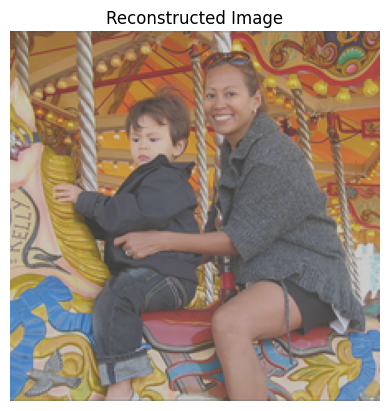

In [110]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Constants
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
IMAGE_CHANNELS = 3
IMAGE_SIZE = IMAGE_HEIGHT * IMAGE_WIDTH * IMAGE_CHANNELS
IMAGE_DTYPE = np.int8
BIN_FILE = "images.bin"

# --- 1. Load the first image from binary ---
with open(BIN_FILE, "rb") as f:
    raw = f.read(IMAGE_SIZE)  # Read the first image only
    img_q = np.frombuffer(raw, dtype=IMAGE_DTYPE).reshape((IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS))

# --- 2. Dequantize (reverse of (int8 - 128)) ---
img_f = np.clip(img_q.astype(np.int32) + 128, 0, 255).astype(np.uint8)

# --- 3. Display the reconstructed image ---
plt.imshow(img_f)
plt.title("Reconstructed Image")
plt.axis("off")
plt.show()


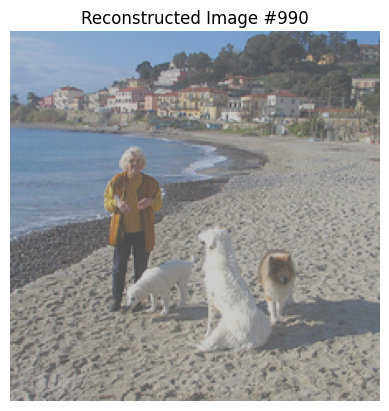

In [113]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Constants
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
IMAGE_CHANNELS = 3
IMAGE_SIZE = IMAGE_HEIGHT * IMAGE_WIDTH * IMAGE_CHANNELS  # =150528 bytes per image
IMAGE_DTYPE = np.int8
BIN_FILE = "images.bin"

TARGET_INDEX = 989  # 996th image (0-based indexing)

# --- 1. Load the 996th image ---
with open(BIN_FILE, "rb") as f:
    f.seek(TARGET_INDEX * IMAGE_SIZE)  # Skip first 995 images
    raw = f.read(IMAGE_SIZE)
    if len(raw) != IMAGE_SIZE:
        raise ValueError(f"Image #{TARGET_INDEX+1} not found or file is incomplete.")
    img_q = np.frombuffer(raw, dtype=IMAGE_DTYPE).reshape((IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS))

# --- 2. Dequantize (reverse of (int8 - 128)) ---
img_f = np.clip(img_q.astype(np.int32) + 128, 0, 255).astype(np.uint8)

# --- 3. Display the image ---
plt.imshow(img_f)
plt.title(f"Reconstructed Image #{TARGET_INDEX+1}")
plt.axis("off")
plt.show()


# Number of images that are below 224x224

In [111]:
from PIL import Image
from glob import glob

def count_small_images(folder_path, min_size=(224, 224)):
    image_paths = glob(f"{folder_path}/*")
    small_count = 0
    for path in image_paths:
        try:
            img = Image.open(path)
            if img.width < min_size[0] or img.height < min_size[1]:
                small_count += 1
        except Exception as e:
            print(f"Error reading {path}: {e}")
    return small_count

# Example usage
folder = "Images"  # change this to your image folder
print(f"Number of images smaller than 224x224: {count_small_images(folder)}")


Number of images smaller than 224x224: 24


# Testing the water tower 26814

In [99]:
from PIL import Image
import numpy as np

def preprocess_for_mobilenet_c(image_path):
    # Step 1: Load and resize
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224), Image.BILINEAR)

    # Step 2: Convert to uint8 array
    img_array = np.array(img).astype(np.uint8)  # [0, 255]

    # Step 3: Convert to int8 format used by the C model
    img_int8 = img_array.astype(np.int16) - 128  # Center to [-128, 127]
    img_int8 = np.clip(img_int8, -128, 127).astype(np.int8)

    return img_int8


In [100]:
def preprocess_author_style(image_path):
    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    short_edge = min(w, h)
    img = img.crop(((w - short_edge) // 2,
                    (h - short_edge) // 2,
                    (w + short_edge) // 2,
                    (h + short_edge) // 2))
    img = img.resize((224, 224), Image.BILINEAR)
    img_array = np.array(img).astype(np.int16)
    return np.clip(img_array - 128, -128, 127).astype(np.int8)

In [101]:
def reconstruct_image_from_int8(img_int8):
    img_uint8 = np.clip(img_int8.astype(np.int16) + 128, 0, 255).astype(np.uint8)
    return Image.fromarray(img_uint8)


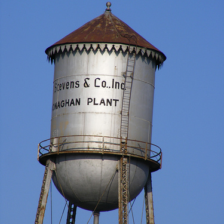

In [103]:
reconstruct_image_from_int8(preprocess_author_style("ImagesTest/ILSVRC2012_val_00026814.JPEG"))